# A Study on Nearby Agriculture Runoff on our Fish Populations

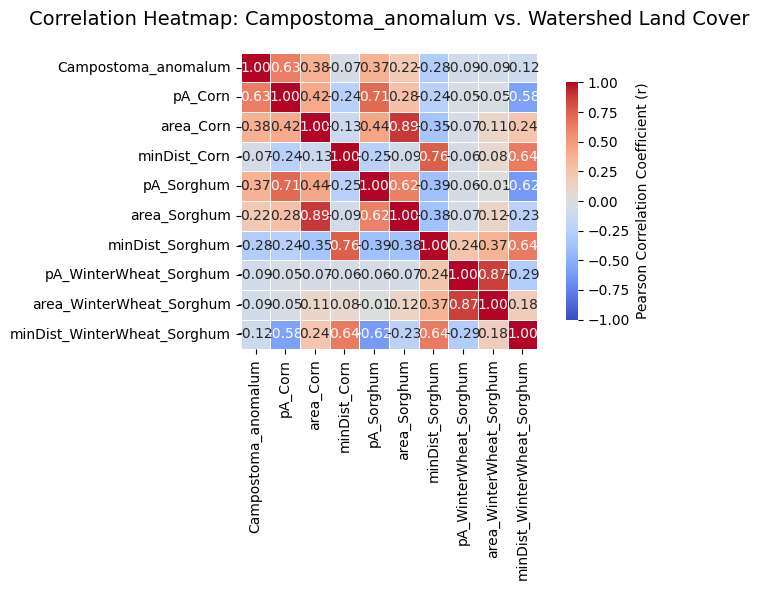

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Isolate the target species and its site key ---
# Replace 'Your_Species_Column_Name' with the exact column name in s_fcd
s_fcd = pd.read_csv('../data/seth_fishCountData_2025.csv')
target_species = 'Campostoma_anomalum'
species_df = s_fcd[['SiteN', target_species]].copy()

# --- 2. Filter your landscape/crop dataframe ---
# Assuming your final crop dataframe is named 'crop_df' 
# Select your site key and the relevant percent area (pA_) columns

crop_df = pd.read_csv('../data/kbrashears_runoff/korbin_hydrologyData_2026.csv')
crop_cols = np.array(crop_df.columns)
crop_cols = [col for col in crop_cols if '_Corn' in col or '_Sorghum' in col]

# Optional: Add other crops/land covers to the heatmap if desired
# crop_cols.extend(['pA_Soybeans', 'pA_WinterWheat']) 

landscape_df = crop_df[crop_cols + ['SiteN']].copy()

# --- 3. Merge the datasets on SiteN ---
merged_df = pd.merge(species_df, landscape_df, on='SiteN', how='inner')

# Drop the spatial index 'SiteN' so it doesn't skew the correlation calculations
analysis_df = merged_df.drop(columns=['SiteN'])

# --- 4. Calculate the Pearson Correlation Matrix ---
corr_matrix = analysis_df.corr(method='pearson')

# --- 5. Generate and Customize the Heatmap Plot ---
plt.figure(figsize=(8, 6))

# Create a mask to hide the redundant upper triangle of the matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,             # Display the correlation coefficients inside the blocks
    fmt=".2f",              # Round values to two decimal places
    cmap='coolwarm',        # Standard scientific diverging color palette
    vmin=-1, vmax=1,        # Lock limits to maximum possible correlation boundaries
    square=True,            # Make cells perfectly square
    linewidths=0.5,         # Separate cells cleanly
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient (r)"}
)

plt.title(f"Correlation Heatmap: {target_species} vs. Watershed Land Cover", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


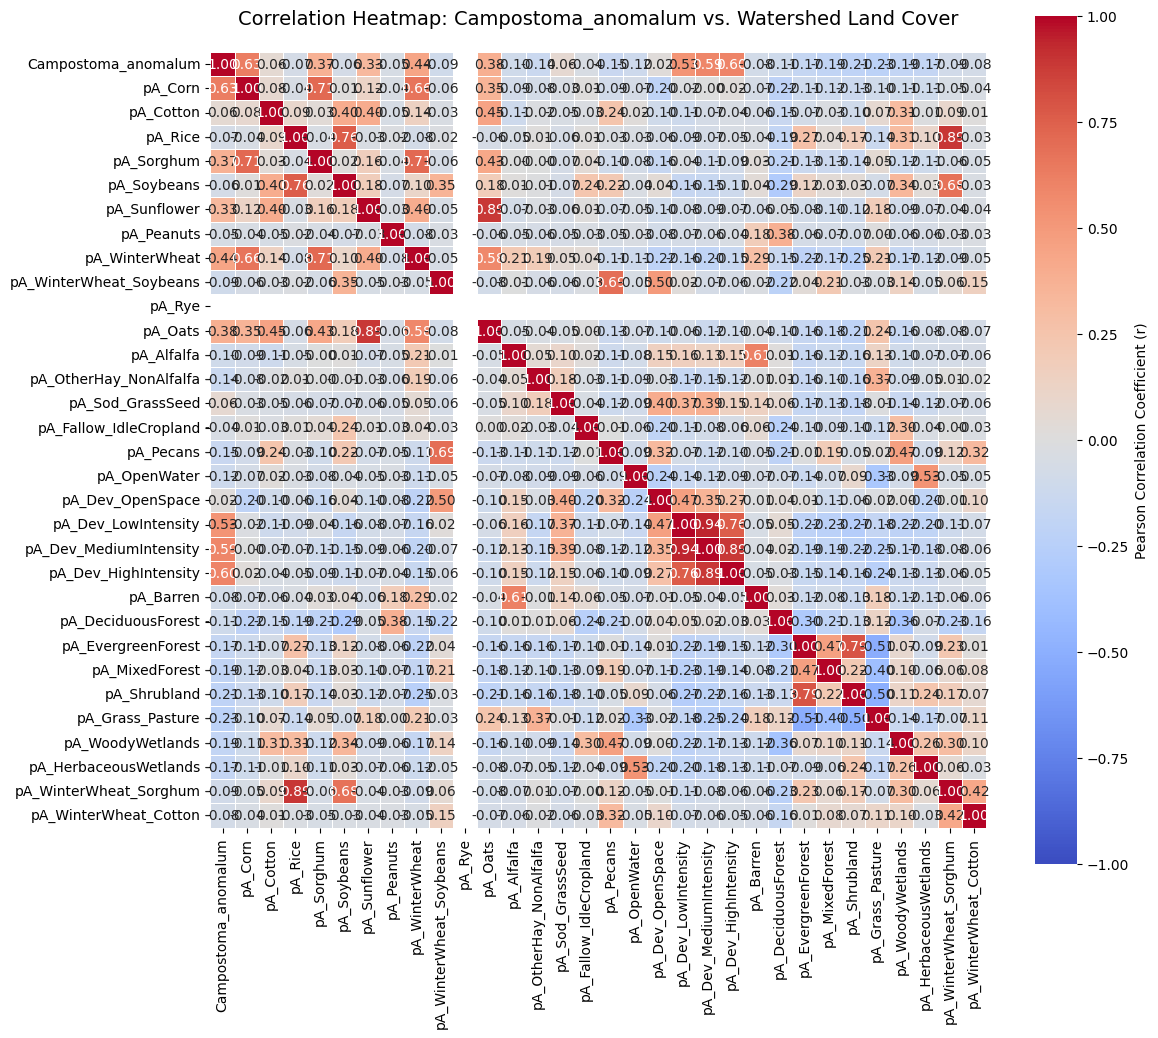

In [21]:
# --- 1. Isolate the target species and its site key ---
# Replace 'Your_Species_Column_Name' with the exact column name in s_fcd
s_fcd = pd.read_csv('../data/seth_fishCountData_2025.csv')
target_species = 'Campostoma_anomalum'
species_df = s_fcd[['SiteN', target_species]].copy()

# --- 2. Filter your landscape/crop dataframe ---
# Assuming your final crop dataframe is named 'crop_df' 
# Select your site key and the relevant percent area (pA_) columns

crop_df = pd.read_csv('../data/kbrashears_runoff/korbin_hydrologyData_2026.csv')
crop_cols = np.array(crop_df.columns)
crop_cols = [col for col in crop_cols if 'pA_' in col]

# Optional: Add other crops/land covers to the heatmap if desired
# crop_cols.extend(['pA_Soybeans', 'pA_WinterWheat']) 

landscape_df = crop_df[crop_cols + ['SiteN']].copy()

# --- 3. Merge the datasets on SiteN ---
merged_df = pd.merge(species_df, landscape_df, on='SiteN', how='inner')

# Drop the spatial index 'SiteN' so it doesn't skew the correlation calculations
analysis_df = merged_df.drop(columns=['SiteN'])

# --- 4. Calculate the Pearson Correlation Matrix ---
corr_matrix = analysis_df.corr(method='pearson')

# --- 5. Generate and Customize the Heatmap Plot ---
plt.figure(figsize=(12, 12))

# Create a mask to hide the redundant upper triangle of the matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,             # Display the correlation coefficients inside the blocks
    fmt=".2f",              # Round values to two decimal places
    cmap='coolwarm',        # Standard scientific diverging color palette
    vmin=-1, vmax=1,        # Lock limits to maximum possible correlation boundaries
    square=True,            # Make cells perfectly square
    linewidths=0.5,         # Separate cells cleanly
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient (r)"}
)

plt.title(f"Correlation Heatmap: {target_species} vs. Watershed Land Cover", fontsize=14, pad=20)
plt.tight_layout()
plt.show()
